# Exercises week 37
##### **Group: Hannah Westgaard, Pernille Xu Amundsen**

**FYS-STK3155/4155, fall 2026 — deadline Friday September 11 at midnight.**



## Implementing gradient descent for ordinary least squares and Ridge regression

The aim this week is that you write, and *check*, your own gradient descent
code for OLS and Ridge regression, and that you understand what the learning
rate can and cannot be. Everything here is reused directly in part e) of
Project 1, and exercise 6 opens part f). The code developed in the Tuesday
session (`week37tuesday.ipynb`, Case 1) is meant to be reused.

After completing these exercises you will have

* your own code for the simplest gradient descent approach applied to
  ordinary least squares (OLS) and Ridge regression, with a stopping criterion;
* compared the analytical expressions for the OLS and Ridge parameters with
  the gradient descent results;
* explored the role of the learning rate $\gamma$ in gradient descent and of the
  hyperparameter $\lambda$ in Ridge regression, and related the largest usable
  learning rate to the largest eigenvalue of the Hessian (Section 4.5 of the
  lecture notes);
* checked your analytical gradient against automatic differentiation
  (Section 4.14) and added momentum (Section 4.6);
* scaled the data properly.

Reading: Chapter 4, Sections 4.1–4.6 and 4.14 of the book; Goodfellow et al.,
Chapter 4 and Sections 8.1–8.3.

## A simple one-dimensional second-order polynomial

We start with a very simple function,

$$
f(x) = 2 - x + 5x^2,
$$

defined for $x \in [-2, 2]$. You can add noise if you wish (the Tuesday
session used Gaussian noise with standard deviation $0.5$). We fit this
function with a polynomial ansatz. The easiest thing is to set up a
second-order polynomial and see if you can recover the above function; feel
free to play around with higher-order polynomials — the Tuesday session shows
that a degree-5 fit of the same data is a much harder problem for gradient
descent, and exercise 4 asks you why.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

## Exercise 1: scale your data

Before fitting a regression model it is good practice to standardise the
features. This ensures all features are on a comparable scale, which is
especially important when using regularisation — and, as Section 4.5 of the
lecture notes shows, it is also what makes gradient descent converge in a
reasonable number of iterations. Here we standardise, scaling each feature to
have mean $0$ and standard deviation $1$.

### 1a)

Set up the design matrix $\boldsymbol{X}$ with the columns $x$ and $x^2$ (no
column of ones). Compute the mean and standard deviation of each column,
subtract the mean and divide by the standard deviation.

We also centre the target $\boldsymbol{y}$ to mean $0$. Centring
$\boldsymbol{y}$ and each feature means the model does not need a separate
intercept term: the data are shifted so that the intercept is effectively
$0$. (In practice one can include an intercept in the model and leave it
unpenalised, see Section 3.13 of the lecture notes; here we simplify by
centring.)

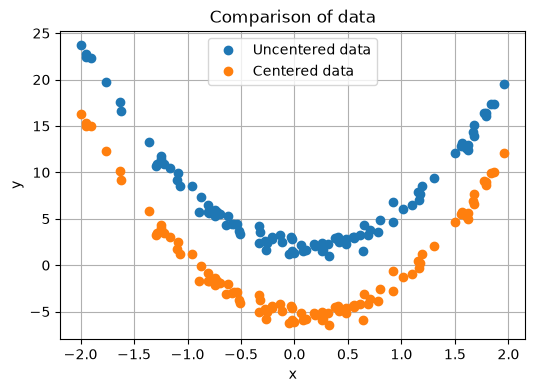

In [2]:
"""Exercise 1a"""
X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = y.mean()
y_centered = y - y_mean

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(x,y, 'o', label='Uncentered data')
ax.plot(x, y_centered, 'o', label='Centered data')
ax.set_title('Comparison of data')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid()
plt.legend()
plt.show()


Fill in the necessary details. Do we need to centre the $y$-values? What
would go wrong, for OLS and for Ridge, if we did not?

After this preprocessing each column of $\boldsymbol{X}_{\mathrm{norm}}$ has
mean zero and standard deviation $1$ and $\boldsymbol{y}_{\mathrm{centered}}$
has mean $0$. This makes the optimisation landscape nicer and ensures that the
penalty $\lambda\sum_j\theta_j^2$ in Ridge regression treats each coefficient
fairly, since the features are on the same scale.


$\bold{Answer}$:

Yes we should centre the y-values as it makes it easier to interpret the intercept term as the expected value of $y_i$ when the predictor values are set to their means. 

So if we do not scale for OLS we would not have an interpretable value for the intercept. 

While for Ridge, as written in 1a. If we do not center the data, the penalty in Ridge Regression will treat the coefficients unfairly as the features will not be on the same scale, thus get penalized differently. 


### 1b)

The true function has coefficients $(-1, 5)$ on $(x, x^2)$. Which
coefficients do you expect to find on the *standardised* columns, and how do
you convert the fitted parameters back to the original scale?

$\bold{Answer}$:

When standardizing the columns, we take each $X_i$ - X-mean $_\text{column}$ / X-std $_\text{column}$. Which in turn gives a column with mean of 0 and std of 1 and a new intercept term. Thus we expect to find changed coefficients as they're now expressed per standard deviation instead of raw data. 

To convert back to the original scale we take new standardized intercept term and divide by the standard deviation.

## Exercise 2: calculate the gradients and the Hessian

Find the gradients of the OLS and Ridge cost functions,

$$
C_{\mathrm{OLS}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2,
\qquad
C_{\mathrm{Ridge}}(\boldsymbol{\theta}) = \frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta} - \boldsymbol{y}\|_2^2 + \lambda\boldsymbol{\theta}^T\boldsymbol{\theta},
$$

with respect to $\boldsymbol{\theta}$ (Eqs. (4.13) and (4.17) of the lecture
notes). Find also the Hessian matrices, and show that the OLS Hessian is
positive semi-definite and the Ridge Hessian positive definite for
$\lambda > 0$ — that is, that both cost functions are convex (Section 4.1).
Why does this matter for gradient descent?

Setting the Ridge gradient to zero, show that the minimiser is
$\hat{\boldsymbol{\theta}} = (\boldsymbol{X}^T\boldsymbol{X} + n\lambda\boldsymbol{I})^{-1}\boldsymbol{X}^T\boldsymbol{y}$.
Where does the factor $n$ come from, and what is the corresponding `alpha`
of `scikit-learn`'s `Ridge`? (Section 3.10 and Eq. (3.95).)

$\bold{Answer}$:

Used Claude to convert handwritten notes to latex syntax

### For OLS

#### Setup

Given

$$
\mathbf{X} = \begin{bmatrix} 1 & x_0 \\ \vdots & \vdots \\ 1 & x_{n-1} \end{bmatrix} \in \mathbb{R}^{n \times 2}, \qquad
\boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix}
$$

we have

$$
\mathbf{X}\boldsymbol{\theta} - \mathbf{y} =
\begin{bmatrix}
\theta_0 + \theta_1 x_0 - y_0 \\
\theta_0 + \theta_1 x_1 - y_1 \\
\vdots \\
\theta_0 + \theta_1 x_{n-1} - y_{n-1}
\end{bmatrix}
\;\Rightarrow\;
\sum_i \theta_0 + \theta_1 x_i - y_i
$$

#### Cost Function

$$
C_{OLS}(\boldsymbol{\theta}) = \frac{1}{n}\left\lVert \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \right\rVert_2^2
= \frac{1}{n} \sum_{i=0}^{n-1} \Big[(\theta_0 + \theta_1 x_i)^2 - 2y_i(\theta_0 + \theta_1 x_i) + y_i^2\Big]
$$

Compute $\partial C / \partial \theta_0$ and $\partial C / \partial \theta_1$ separately, then reassemble.

#### Partial Derivatives

$$
\frac{\partial C}{\partial \theta_0}
= \frac{\partial}{\partial \theta_0}\, \frac{1}{n} \sum_{i=0}^{n-1} \Big[(\theta_0 + \theta_1 x_i)^2 - 2y_i(\theta_0 + \theta_1 x_i) + y_i^2\Big]
= \frac{1}{n}\sum_i \Big[2(\theta_0 + \theta_1 x_i)\cdot 1 - 2y_i \cdot 1\Big]
= \frac{2}{n}\sum_i \big(\theta_0 + \theta_1 x_i - y_i\big)
$$

$$
\frac{\partial C}{\partial \theta_1}
= \frac{\partial}{\partial \theta_1}\, \frac{1}{n} \sum_{i=0}^{n-1} \Big[(\theta_0 + \theta_1 x_i)^2 - 2y_i(\theta_0 + \theta_1 x_i) + y_i^2\Big]
= \frac{1}{n}\sum_i \Big[2(\theta_0 + \theta_1 x_i)x_i - 2y_i x_i\Big]
= \frac{2}{n}\sum_i \big(x_i(\theta_0 + \theta_1 x_i) - y_i x_i\big)
$$

#### Gradient (Reassembled)

$$
\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta})
= \frac{2}{n}
\begin{bmatrix}
\sum_i (\theta_0 + \theta_1 x_i - y_i) \\
\sum_i \big(x_i(\theta_0 + \theta_1 x_i) - y_i x_i\big)
\end{bmatrix}
= \frac{2}{n}
\begin{bmatrix}
\sum_i (\theta_0 + \theta_1 x_i - y_i) \\
\sum_i x_i\big[(\theta_0 + \theta_1 x_i) - y_i\big]
\end{bmatrix}
= \frac{2}{n}
\begin{bmatrix}
\mathbf{1}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) \\
\mathbf{x}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
\end{bmatrix}
$$

Given $\mathbf{X}^T = \begin{bmatrix} \mathbf{1}^T \\ \mathbf{x}^T \end{bmatrix}$,

$$
\Rightarrow\;
\frac{2}{n}
\begin{bmatrix} \mathbf{1}^T \\ \mathbf{x}^T \end{bmatrix}
\big[\mathbf{X}\boldsymbol{\theta} - \mathbf{y}\big]
= \boxed{\dfrac{2}{n}\, \mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})}
$$

#### Hessian

Writing it out by coordinate we get:

$$
\mathbf{H} =
\begin{bmatrix}
\dfrac{\partial^2 C}{\partial \theta_0^2} & \dfrac{\partial^2 C}{\partial \theta_0 \partial \theta_1} \\[2ex]
\dfrac{\partial^2 C}{\partial \theta_1 \partial \theta_0} & \dfrac{\partial^2 C}{\partial \theta_1^2}
\end{bmatrix}
$$

The elements of the matrix are thus:

$$
\frac{\partial^2 C}{\partial \theta_0^2}
= \frac{\partial}{\partial \theta_0}\, \frac{2}{n}\sum_i (\theta_0 + \theta_1 x_i - y_i)
= \frac{2}{n}\sum_i 1
$$

$$
\frac{\partial^2 C}{\partial \theta_0 \partial \theta_1}
= \frac{\partial}{\partial \theta_0}\, \frac{2}{n}\sum_i \big(x_i(\theta_0 + \theta_1 x_i) - y_i x_i\big)
= \frac{2}{n}\sum_i x_i
$$

$$
\frac{\partial^2 C}{\partial \theta_1 \partial \theta_0}
= \frac{\partial}{\partial \theta_1}\, \frac{2}{n}\sum_i (\theta_0 + \theta_1 x_i - y_i)
= \frac{2}{n}\sum_i x_i
$$

$$
\frac{\partial^2 C}{\partial \theta_1^2}
= \frac{\partial}{\partial \theta_1}\, \frac{2}{n}\sum_i \big(x_i(\theta_0 + \theta_1 x_i) - y_i x_i\big)
= \frac{2}{n}\sum_i x_i^2
$$

#### Hessian (Reassembled)

$$
\Rightarrow\;
\mathbf{H} = \frac{2}{n}
\begin{bmatrix}
\sum_i 1 & \sum_i x_i \\
\sum_i x_i & \sum_i x_i^2
\end{bmatrix}
= \frac{2}{n}
\begin{bmatrix} \mathbf{1}^T \\ \mathbf{x}^T \end{bmatrix}
\begin{bmatrix} \mathbf{1} & \mathbf{x} \end{bmatrix}
= \boxed{\dfrac{2}{n}\, \mathbf{X}^T \mathbf{X}}
$$



### For Ridge:

#### Cost Function

$$
C_{RIDGE}(\boldsymbol{\theta}) = \frac{1}{n}\left\lVert \mathbf{X}\boldsymbol{\theta} - \mathbf{y} \right\rVert_2^2 + \lambda \boldsymbol{\theta}^T\boldsymbol{\theta}
$$

Reuse the answer from OLS, since it's the same for the first term. Calculate the second term:

$$
\lambda \boldsymbol{\theta}^T\boldsymbol{\theta} = \lambda
\begin{bmatrix} \theta_0 & \theta_1 \end{bmatrix}
\begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix}
= \lambda(\theta_0^2 + \theta_1^2)
$$

$$
\frac{\partial}{\partial \theta_0}\, \lambda(\theta_0^2 + \theta_1^2) = 2\lambda\theta_0
\qquad
\frac{\partial}{\partial \theta_1}\, \lambda(\theta_0^2 + \theta_1^2) = 2\lambda\theta_1
$$

## Gradient

Since the terms are separable, we know that

$$
\nabla_{\boldsymbol{\theta}} C_{RIDGE}(\boldsymbol{\theta})\big[\text{term 1}\big] = \frac{2}{n}\mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})
$$

while the second term gives

$$
\begin{bmatrix} 2\lambda\theta_0 \\ 2\lambda\theta_1 \end{bmatrix} = 2\lambda\boldsymbol{\theta}
$$

So the whole gradient is:

$$
\nabla_{\boldsymbol{\theta}} C_{RIDGE}(\boldsymbol{\theta}) = \boxed{\dfrac{2}{n}\mathbf{X}^T(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}) + 2\lambda\boldsymbol{\theta}}
$$

## Hessian

$\mathbf{H}$ follows the same logic but with $2\lambda\boldsymbol{\theta}$:

$$
\mathbf{H} = \frac{2}{n}\mathbf{X}^T\mathbf{X} +
\begin{bmatrix}
\dfrac{\partial^2 \lambda\boldsymbol{\theta}^T\boldsymbol{\theta}}{\partial \theta_0^2} & \dfrac{\partial^2 \lambda\boldsymbol{\theta}^T\boldsymbol{\theta}}{\partial \theta_0 \partial \theta_1} \\[2ex]
\dfrac{\partial^2 \lambda\boldsymbol{\theta}^T\boldsymbol{\theta}}{\partial \theta_1 \partial \theta_0} & \dfrac{\partial^2 \lambda\boldsymbol{\theta}^T\boldsymbol{\theta}}{\partial \theta_1^2}
\end{bmatrix}
$$

We calculate the matrix elements, giving:

$$
\frac{\partial}{\partial \theta_0} 2\lambda\theta_0 = 2\lambda, \qquad
\frac{\partial}{\partial \theta_0} 2\lambda\theta_1 = 0
$$

$$
\frac{\partial}{\partial \theta_1} 2\lambda\theta_0 = 0, \qquad
\frac{\partial}{\partial \theta_1} 2\lambda\theta_1 = 2\lambda
$$

$$
=
\begin{bmatrix} 2\lambda & 0 \\ 0 & 2\lambda \end{bmatrix}
= 2\lambda
\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
= 2\lambda \mathbf{I}
$$

Thus:

$$
\mathbf{H} = \boxed{\dfrac{2}{n}\mathbf{X}^T\mathbf{X} + 2\lambda \mathbf{I}}
$$



If matrix is positive semi-definite, $\vec x^T A \vec x \geq 0$ for all real vector $\vec x$.

so Hessian OLS = $\frac{2}{n}\vec X^T\vec X$, use vector $\vec v$

$$\vec v^T\left(\frac{2}{n}\vec X^T\vec X\right)\vec v = \frac{2}{n}\vec v^T \vec X^T \vec X \vec v$$

$$= \frac{2}{n}(\vec X\vec v)^T\vec X\vec v = \frac{2}{n}\|\vec X\vec v\|^2 \geq 0 \quad \text{Thus positive semi-definite} $$

For Hessian Ridge know 1st term $\frac{2}{n}\|\vec X\vec v\|^2 \geq 0$

so 2nd term: $\vec v^T(2\lambda\vec I)\vec v = 2\lambda\vec v^T\vec I \vec v = 2\lambda\vec v^T\vec v = 2\lambda\|\vec v\|^2 \geq 0$ if $\lambda > 0$

Thus $\frac{2}{n}\vec X^T\vec X + 2\lambda\vec I$ is positive definite for $\lambda > 0$.


Which means that both cost functions are convex, which means that the functions minimum value is the global minimum as it only has one minimum. So gradient will point towards this minimum, so the gradient descent won't converge to any random minimum as there doesn't exist any others than the minimum it converges towards.

Ridge gradient = 0, means that

$$\Rightarrow \frac{2}{n}\vec X^T(\vec X\vec\theta-\vec y) + 2\lambda\vec\theta = 0 \quad |\div 2$$

$$\Rightarrow \frac{1}{n}\vec X^T\vec X\vec\theta - \frac{1}{n}\vec X^T\vec y + \lambda\vec\theta = 0  \quad | \text{isolate } \vec\theta$$

$$\Rightarrow \frac{1}{n}\vec X^T\vec X\vec\theta + \lambda\vec\theta = \frac{1}{n}\vec X^T\vec y$$

$$\Rightarrow \left(\frac{1}{n}\vec X^T\vec X + \lambda\right)\vec\theta = \frac{1}{n}\vec X^T\vec y \quad |\times n$$

$$\Rightarrow \left(\vec X^T\vec X + n\lambda\right)\vec\theta = \vec X^T\vec y$$

$$\vec\theta = \left(\vec X^T\vec X + n\lambda\right)^{-1}\vec X^T\vec y$$

The n comes from the cost function (1/n).

Ridge minimizes the objective function: $\|\vec y - \vec X\vec w\|_2^2 + \alpha\|\vec w\|_2^2$ (from Ridge in scikit-learn.org)

our function: $\frac{1}{n}\|\vec X\vec\theta-\vec y\|_2^2 + \lambda\|\vec\theta\|_2^2$

no n in Ridge. Thus minimizer theta for scikitlearn is : $\vec X^T\vec X + \alpha\vec I$

While our minimizer theta is: $\vec X^T\vec X + n\lambda\vec I$. 

Therefore $$\alpha = n\lambda \quad \text{so} \quad n = \frac{\alpha}{\lambda}$$

## Exercise 3: the analytical formulae for OLS and Ridge regression

Exercise 3a
Closed-form OLS coefficients: [-1.0773505  5.854734 ]
Closed-form Ridge coefficients: [-0.99352625  5.5664798 ]
Sklearn closed form [-0.99352625  5.5664798 ]
Max | our model - sklearns | for Ridge is: 1.1e-16 

Exercise 3b


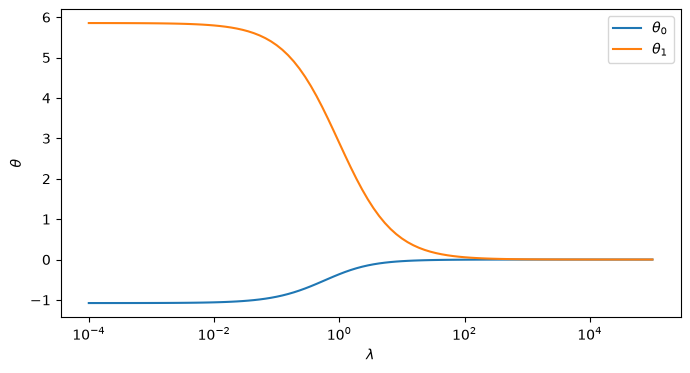

In [3]:
from sklearn.linear_model import Ridge

"""Exercise 3a"""
print('Exercise 3a')
# Set regularization parameter, either a single value or a vector of values
# Note that lambda is a python keyword: the lambda keyword creates small anonymous functions.
lam = 0.05

#Function taken from seminar
def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

#Analytically solving for theta closed form for ridge and ols using closed form function
theta_closed_formRidge = closed_form(X_norm, y_centered, lam)
theta_closed_formOLS = closed_form(X_norm, y_centered)

#using sklearns function
theta_closed_form_sklearn = Ridge(alpha=n*lam, fit_intercept=False).fit(X_norm, y_centered).coef_

#compare
print("Closed-form OLS coefficients:", theta_closed_formOLS)
print("Closed-form Ridge coefficients:", theta_closed_formRidge)
print('Sklearn closed form', theta_closed_form_sklearn)

#find max differnce between our function vs sklearns to see how good they hold
diff = np.max(np.abs(theta_closed_formRidge - theta_closed_form_sklearn))

print(f'Max | our model - sklearns | for Ridge is: {diff:.1e}', '\n')


"""Exercise 3b"""
print('Exercise 3b')
lam_list = np.logspace(-4,5,100)
theta_list = []

for lam in lam_list:
    theta_closed_formRidge = closed_form(X_norm, y_centered, lam)
    theta_closed_form_sklearn = Ridge(alpha=n*lam, fit_intercept=False).fit(X_norm, y_centered).coef_
    diff = np.max(np.abs(theta_closed_formRidge - theta_closed_form_sklearn))

    theta_list.append(theta_closed_formRidge)

theta_list = np.array(theta_list)
fig, ax = plt.subplots(figsize=(8,4))

for i in range(X_norm.shape[1]):
    ax.plot(lam_list, theta_list[:,i], label=rf'$\theta_{i}$')

ax.set_xscale('log')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\theta$')
ax.legend()
plt.show()

This computes the Ridge and OLS regression coefficients directly. The identity
matrix $\boldsymbol{I}$ has the same size as $\boldsymbol{X}^T\boldsymbol{X}$
and adds $n\lambda$ to its diagonal for Ridge regression. We then solve the
linear system (prefer `np.linalg.solve` or `np.linalg.pinv` to an explicit
inverse). The result for $\boldsymbol{\theta}$ is a NumPy array of shape
`(n_features,)` containing the fitted parameters.

### 3a)

Finalise, in the above code, the OLS and Ridge regression determination of
the optimal parameters $\boldsymbol{\theta}$. Compare with
`Ridge(alpha=n*lam, fit_intercept=False)` from `scikit-learn`.

$\bold{Answer}:$

From output above we can see that the difference is so small it does not matter if we use our code or scikit learns.

### 3b)

Explore the results as functions of different values of the hyperparameter
$\lambda$. See for example exercise 4 from week 36, and Section 3.14 of the
lecture notes for how $\lambda$ should be chosen in practice.

## Exercise 4: implementing the simplest form of gradient descent

Alternatively we can fit the model by gradient descent, Eq. (4.15) of the
lecture notes,

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \gamma\,\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k).
$$

This is useful to visualise the iterative convergence, and it is necessary
when $n$ and $p$ are so large that the closed form is too slow or too
memory-hungry — or when, as for the Lasso, logistic regression and neural
networks, no closed form exists. Use the gradients of exercise 2 and set up,
using the template below, your own gradient descent code for OLS and Ridge
regression.

$\bold{Answer:}$:

From Figure output above, we see that for smaller $\lambda$'s, both theta's sit at what appears to be the values for closed form OLS (-1.08, -5.85). This means that smaller lambdas will give OLS regression which seems plausible as OLS is just Ridge but with $\lambda$ = 0. 

We see that as $\lambda$ increases, the coefficints shrink towards 0 as the penalty will start dominating the cost function. And towards around $\lambda$ = 1e2 both coefficients flatten at 0, whch means that the penalty term for Ridge regression has taken over.

### 4a)

Write first a gradient descent code for OLS only, using the above template.
Discuss the results as functions of the learning rate and the number of
iterations: for $\gamma \in \{0.01, 0.1, 0.5, 0.8\}$, how many iterations are
needed to reach the closed-form solution of exercise 3 to a given accuracy,
say $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$?
Plot this distance against the iteration number on a logarithmic scale.

Exercise 4a
Closed form OLS: [-1.0774  5.8547]
gamma = 0.01 :   1158 iterations, |theta - closed form| =  5.55e-09   converged
gamma = 0.1  :    108 iterations, |theta - closed form| =  3.92e-09   converged
gamma = 0.5  :     11 iterations, |theta - closed form| =  3.84e-10   converged
gamma = 0.8  :     88 iterations, |theta - closed form| =  3.15e-09   converged


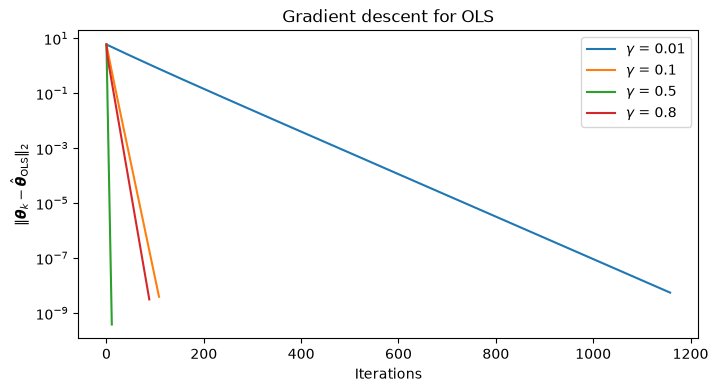

In [4]:
"""Exercise 4a"""
print('Exercise 4a')

"""Function based on those from Tuesday seminar"""
def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

"""Based on what lambda is it works for either OLS or Ridge"""
def gradient_descent(X, y, gamma, lam=0.0, num_iters=1000, tol=1e-8, theta0=None):
    """Plain gradient descent, Eq. (4.15). Returns the iterates and the number of steps."""
    p = X.shape[1]
    theta = np.zeros(p) if theta0 is None else theta0.copy()
    history = [theta.copy()]

    for t in range(num_iters):
        grad = gradient(theta, X, y, lam) 
        theta = theta - gamma * grad
        history.append(theta.copy())
        if np.linalg.norm(grad) < tol:
            break
    return np.array(history), t + 1


# Gradient descent parameters, learning rate gamma first
gammas = [0.01, 0.1, 0.5, 0.8]
num_iters = 1500    #if at 1000 then gamma = 0.01 does not converge


print('Closed form OLS:', np.round(theta_closed_formOLS,4))
fig, ax = plt.subplots(figsize=(8,4))

for i in range(len(gammas)):
    theta_gdOLS, iterations = gradient_descent(X_norm, y_centered, gammas[i], num_iters=num_iters)
    diff_theta = np.linalg.norm(theta_gdOLS[-1] - theta_closed_formOLS)
    status = "converged" if iterations < num_iters and np.isfinite(diff_theta) else ("DIVERGED" if not np.isfinite(diff_theta) or diff_theta > 1e3 else "not converged")
    print(f"gamma = {gammas[i]:<5}: {iterations:6d} iterations, |theta - closed form| = {diff_theta:9.2e}   {status}")

    distance = np.linalg.norm(theta_gdOLS - theta_closed_formOLS, axis=1)

    ax.plot(range(len(distance)), distance, label=rf'$\gamma$ = {gammas[i]}')
    ax.set_title('Gradient descent for OLS')
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    ax.set_yscale('log')

ax.legend()
plt.show()
    

### 4b)

Write then a similar code for Ridge regression. Add a stopping criterion
based on the number of iterations *and* on the size of the gradient (or on
the difference between the new and old $\boldsymbol{\theta}$). How would you
define a stopping criterion, and what goes wrong with a fixed number of
iterations alone?

gamma = 0.01 :   1039 iterations, |theta - closed form| =  4.98e-09   converged
gamma = 0.1  :     96 iterations, |theta - closed form| =  3.41e-09   converged
gamma = 0.5  :     15 iterations, |theta - closed form| =  3.82e-10   converged
gamma = 0.8  :    396 iterations, |theta - closed form| =  3.87e-09   converged


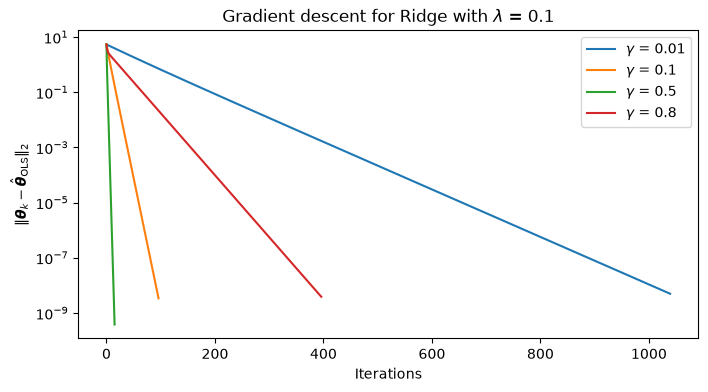

In [5]:
# Gradient descent parameters, learning rate gamma first
gammas = [0.01, 0.1, 0.5, 0.8]
num_iters = 1500
lambus = 0.1
fig, ax = plt.subplots(figsize=(8,4))

for i in range(len(gammas)):
    theta_closed_formRidge = closed_form(X_norm, y_centered, lambus)
    theta_gdRidge, iterations = gradient_descent(X_norm, y_centered, gammas[i], lam=lambus, num_iters=num_iters)
    diff_theta = np.linalg.norm(theta_gdRidge[-1] - theta_closed_formRidge)
    status = "converged" if iterations < num_iters and np.isfinite(diff_theta) else ("DIVERGED" if not np.isfinite(diff_theta) or diff_theta > 1e3 else "not converged")
    print(f"gamma = {gammas[i]:<5}: {iterations:6d} iterations, |theta - closed form| = {diff_theta:9.2e}   {status}")

    distance = np.linalg.norm(theta_gdRidge - theta_closed_formRidge, axis=1)

    ax.plot(range(len(distance)), distance, label=rf'$\gamma$ = {gammas[i]}')

    
ax.set_title(rf'Gradient descent for Ridge with $\lambda$ = {lambus}')
ax.set_xlabel('Iterations')
ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
ax.set_yscale('log')

ax.legend()
plt.show()

### 4c) The learning rate and the eigenvalues of the Hessian

Compute the eigenvalues $\lambda_{\max}$ and $\lambda_{\min}$ of the Hessian
matrix of exercise 2 (use `np.linalg.eigvalsh`). Section 4.5 of the lecture
notes shows that gradient descent converges if and only if
$\gamma < 2/\lambda_{\max}$, Eq. (4.20), that the fastest convergence is
obtained for $\gamma^* = 2/(\lambda_{\max} + \lambda_{\min})$, and that the
number of iterations grows with the condition number
$\kappa = \lambda_{\max}/\lambda_{\min}$, Eq. (4.21). Verify the bound
numerically: run your code at $0.99 \cdot 2/\lambda_{\max}$ and at
$1.02 \cdot 2/\lambda_{\max}$.

Repeat for a design matrix with the columns $x, x^2, \dots, x^5$
(standardised). What happens to $\kappa$, to $\gamma_{\max}$ and to the number
of iterations, and why? Which of the two data sets does Ridge regression help
more, and in what sense?

$\bold{Answer:}$

From output below, we see that increasing the design matrix from 2 to 5 degrees, increases $\kappa$ from 1.27 (OLS) and 1.24 (Ridge) to 520.34 (OLS) and 27.76 (Ridge). While $\gamma_{\max}$ will decrease from 0.8941 (OLS) and 0.8207 (Ridge) to 0.3538 (OLS) and 0.3417 (Ridge). 

We also see that the number of iterations will increase. $\kappa$ is the condition number and quatifies sensitivity. So a higher $\kappa$ means that the model is more sensitive to noise which translates to a harder to follow gradience in graidence descent. This can be seen as when we have smaller $\kappa$'s, number of iterations are lower (i.e they converge faster). We know that increasing polynomial degree makes a more complex model which is thus more sensitive as they're often variance dominated as seen from previous weekly task.

Ridge must help design matrix for 5 degrees the most, as the difference between their $\kappa$'s are so large at 492.58 compared to 2-degree design matrix $\kappa$ difference at 0.03. This differnce can only come from the penalty $\lambda$ work on Ridge regression for a more complex model.


Eigenvalues in ascending order for OLS Hessian matrix is [1.7631, 2.2369]
Eigenvalues in ascending order for Ridge Hessian matrix with Lambda = 0.1 is: [1.9631, 2.4369]
Design matrix to 2nd degree 

121
1000
1000


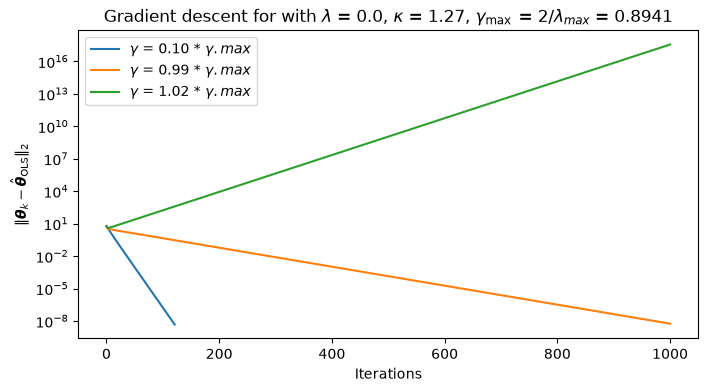

119
1000
1000


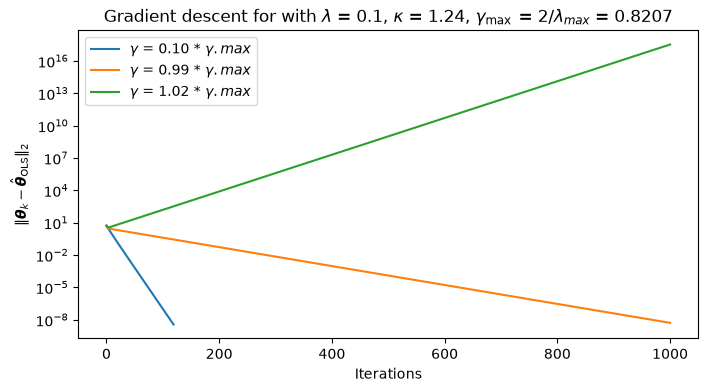

Design matrix to 5th degree
Eigenvalues in ascending order for OLS Hessian matrix (5th degree) is [0.0109, 5.6527]
Eigenvalues in ascending order for Ridge Hessian matrix (5th degree) with Lambda = 0.1 is: [0.2109, 5.8527] 

1000
1000
1000


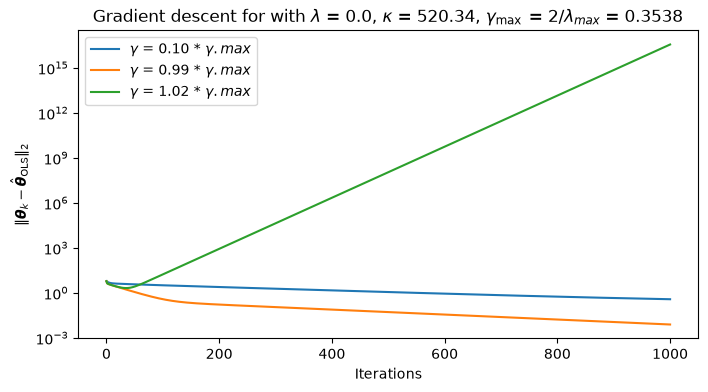

1000
946
1000


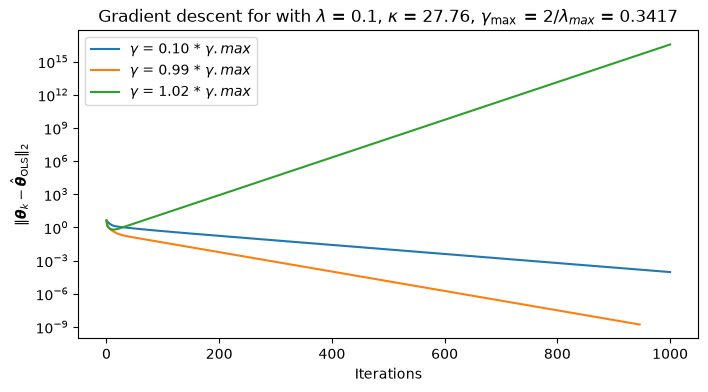

In [11]:
def hess_eigvals(X,lam=0.0):
    '''Computed eignvalues lam_max, lam_min of Hesisan matrix of exercise 2.
    Works for OLS and Ridge depending on lambda value'''
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

def convergence_vals(X, lam=0.0):
    eig_val = hess_eigvals(X, lam)
    lam_max, lam_min = eig_val.max(), eig_val.min()
    gamma_star = 2 / (lam_max + lam_min)
    gamma_max = 2 / lam_max
    kappa = lam_max / lam_min

    return lam_max, lam_min, gamma_star, gamma_max, kappa

lam_max_OLS, lam_min_OLS, gamma_star_OLS, gamma_max_OLS, kappa_OLS = convergence_vals(X_norm)
lam_max_R, lam_min_R, gamma_star_R, gamma_max_R, kappa_R = convergence_vals(X_norm,lambus)

print(f'Eigenvalues in ascending order for OLS Hessian matrix is [{lam_min_OLS:.4f}, {lam_max_OLS:.4f}]')
print(f'Eigenvalues in ascending order for Ridge Hessian matrix with Lambda = {lambus} is: [{lam_min_R:.4f}, {lam_max_R:.4f}]')

print(f'Design matrix to 2nd degree', '\n')

def gd_convergence_plot(X,y, gamma_max, theta_cf, kappa, lam=0.0, num_iters=1000):
    gammas = [0.1*gamma_max, 0.99*gamma_max, 1.02*gamma_max]
    fig, ax = plt.subplots(figsize=(8,4))
    for gamma in gammas:
        theta, iterations = gradient_descent(X,y, gamma, lam=lam, num_iters=num_iters, tol=1e-8)
        print(iterations)
        distance = np.linalg.norm(theta - theta_cf, axis=1)
        ax.plot(range(len(distance)), distance, label=rf'$\gamma$ = {gamma/gamma_max:.2f} * $\gamma.max$')
        
        
    ax.set_title(rf'Gradient descent for with $\lambda$ = {lam}, $\kappa$ = {kappa:.2f}, $\gamma_{{\max}}$ = 2/$\lambda_{{max}}$ = {gamma_max:.4f}')
    ax.set_xlabel('Iterations')
    ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
    ax.set_yscale('log')
    ax.legend()
    plt.show()

#Plot how the different gammas converge for OLS and Ridge (lambda = 0.1)
gd_convergence_plot(X_norm,y_centered, gamma_max_OLS, theta_closed_formOLS, kappa_OLS)
gd_convergence_plot(X_norm,y_centered, gamma_max_R, theta_closed_formRidge, kappa_R, lam=lambus)

"""For new design matrix """
print('Design matrix to 5th degree')
# Standardize features (zero mean, unit variance for each feature)
X5 = np.column_stack([x, x**2, x**3, x**4, x**5])
X5_mean = X5.mean(axis=0)
X5_std = X5.std(axis=0)
X5_std[X5_std == 0] = 1   # safeguard to avoid division by zero for constant features
X5_norm = (X5 - X5_mean) / X5_std

X5_theta_cf_OLS = closed_form(X5_norm, y_centered)
X5_theta_cf_R = closed_form(X5_norm, y_centered, lam=lambus)

X5_lam_max_OLS, X5_lam_min_OLS, X5_gamma_star_OLS, X5_gamma_max_OLS, X5_kappa_OLS = convergence_vals(X5_norm)
X5_lam_max_R, X5_lam_min_R, X5_gamma_star_R, X5_gamma_max_R, X5_kappa_R = convergence_vals(X5_norm,lambus)

print(f'Eigenvalues in ascending order for OLS Hessian matrix (5th degree) is [{X5_lam_min_OLS:.4f}, {X5_lam_max_OLS:.4f}]')
print(f'Eigenvalues in ascending order for Ridge Hessian matrix (5th degree) with Lambda = {lambus} is: [{X5_lam_min_R:.4f}, {X5_lam_max_R:.4f}]', '\n')

gd_convergence_plot(X5_norm,y_centered, X5_gamma_max_OLS, X5_theta_cf_OLS, X5_kappa_OLS)
gd_convergence_plot(X5_norm,y_centered, X5_gamma_max_R, X5_theta_cf_R, X5_kappa_R, lam=lambus)




### 4d) Checking the gradient with automatic differentiation

Project 1, part e), asks you to compute the gradient in two independent ways:
analytically, and by automatic differentiation. Write the OLS and Ridge cost
functions as ordinary Python functions of $\boldsymbol{\theta}$ using
`jax.numpy`, obtain their gradients with `jax.grad`, and compare with your
analytical gradients from exercise 2 at a random $\boldsymbol{\theta}$
(Section 4.14.7 of the lecture notes; remember
`jax.config.update("jax_enable_x64", True)`). Run your gradient descent code
with the automatic gradient and check that you obtain the same iterates.

In one or two sentences: why is automatic differentiation neither symbolic
nor numerical (finite-difference) differentiation, and what does a gradient
cost relative to one evaluation of the cost function (Section 4.14.4)?

$\bold{Answer:}$

Symbolic differentiaion manipulates expressions, takes formula for f and returns formula for f', while numerical differation replaces the derivative by a difference quotient. 

Automatic differention computes the numerival value of the derivative at a point (not a formula), so no expression and it does it by propagating exact derivate rules through the program.

We can see that the diferrence between analytical (closed form) and jax.numpy is very is so minimal for both OLS and Ridge at 1e-16 that it does not matter which we use.

In [12]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import grad

n, p = X_norm.shape
def cost_OLS(theta, X, y):
    return jnp.sum((X @ theta - y)**2) / len(y)

def cost_Ridge(theta, X, y, lam):
    return jnp.sum((X @ theta - y)**2)  / len(y) + lam * jnp.sum(theta.T @ theta)

theta_test = np.random.default_rng(2026).standard_normal(X_norm.shape[1])

grad_OLS_ad = grad(cost_OLS)(theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered))
grad_OLS_analytical = gradient(theta_test,X_norm,y_centered)

grad_Ridge_ad = grad(cost_Ridge)(theta_test, jnp.asarray(X_norm), jnp.asarray(y_centered), lambus)
grad_Ridge_analytical = gradient(theta_test,X_norm,y_centered, lam=lambus)


print("OLS: max |AD - analytical| =", np.max(np.abs(grad_OLS_ad - grad_OLS_analytical)))
print("Ridge: max |AD - analytical| =", np.max(np.abs(grad_Ridge_ad - grad_Ridge_analytical)))


OLS: max |AD - analytical| = 1.1102230246251565e-16
Ridge: max |AD - analytical| = 1.1102230246251565e-16


## Exercise 5: Ridge regression and a new synthetic data set

We create a synthetic linear regression data set with a sparse underlying
relationship: many features, of which only a few contribute to the target. We
use 10 features with only 3 non-zero weights in the true model, so that the
target is a linear combination of a few features (with known coefficients)
plus random noise. The steps are:

* decide on the number of samples and features (100 samples, 10 features);
* define the *true* coefficient vector with mostly zeros, for example
  $\boldsymbol{\theta}_{\mathrm{true}} = [5.0, -3.0, 0, 0, 0, 0, 2.0, 0, 0, 0]$,
  meaning only features 0, 1 and 6 have a real effect on $y$;
* sample the feature matrix $\boldsymbol{X}$ from a standard normal
  distribution, so that the features are roughly centred around 0;
* compute $\boldsymbol{y} = \boldsymbol{X}\boldsymbol{\theta}_{\mathrm{true}} + \boldsymbol{\varepsilon}$
  with Gaussian noise $\boldsymbol{\varepsilon}$.

True values:             [ 5. -3.  0.  0.  0.  0.  2.  0.  0.  0.]
OLS regression:          [ 4.97 -2.89 -0.13  0.01 -0.01  0.04  1.96  0.04 -0.03  0.01]
OLS Gradiant Descent:    [ 4.97 -2.89 -0.13  0.01 -0.01  0.04  1.96  0.04 -0.03  0.01]
Ridge regression:        [ 4.53 -2.65 -0.18  0.03 -0.01  0.06  1.78 -0.01 -0.02  0.05]
Ridge Gradiant Descent:  [ 4.53 -2.65 -0.18  0.03 -0.01  0.06  1.78 -0.01 -0.02  0.05]


Condition number for OLS of the Hessian is 3.32
Condition number for Ridge of the Hessian with lambda= 0.1 is 2.92
288
977
1000


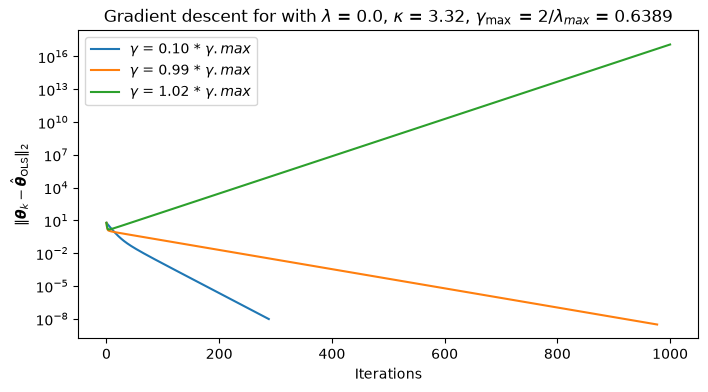

252
977
1000


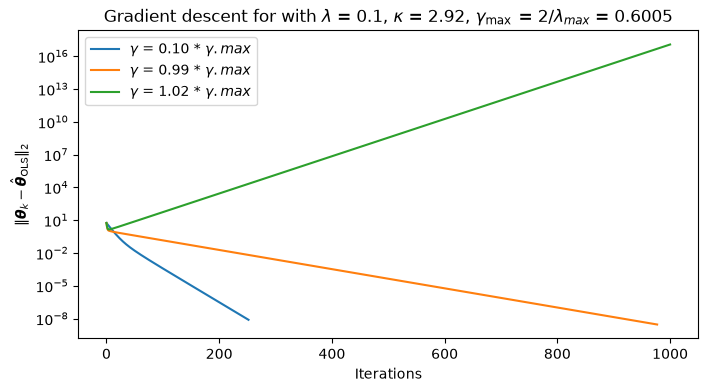

In [13]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(2026)

# Define dataset size
n_samples = 100
n_features = 10

lambus = 0.1
# Define true coefficients (sparse linear relationship)
theta_true = np.array([5.0, -3.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0])

# Generate feature matrix X (n_samples x n_features) with random values
Xn= np.random.randn(n_samples, n_features)  # standard normal distribution

# Standardize features (zero mean, unit variance for each feature)
Xn_mean = Xn.mean(axis=0)
Xn_std = Xn.std(axis=0)
Xn_std[Xn_std == 0] = 1  # safeguard to avoid division by zero for constant features
Xn_norm = (Xn - Xn_mean) / Xn_std

# Generate target values y with a linear combination of X and theta_true, plus noise
noise = 0.5 * np.random.randn(n_samples)    # Gaussian noise
yn = Xn_norm @ theta_true + noise 
yn_centered = yn - yn.mean()

gamma = 0.1


print(f'True values:            ', np.round(theta_true,4))

"""Analytical (via closed form) and gradient descent thetas for ridge and ols"""
theta_cf_OLS = closed_form(Xn_norm,yn_centered)
theta_cf_R = closed_form(Xn_norm, yn_centered, lambus)
theta_gdOLS, _ = gradient_descent(Xn_norm, yn_centered, gamma)
theta_gdR, _ = gradient_descent(Xn_norm, yn_centered, gamma,lam=lambus)

print('OLS regression:         ', np.round(theta_cf_OLS,2))
print('OLS Gradiant Descent:   ', np.round(theta_gdOLS[-1],2))

print('Ridge regression:       ', np.round(theta_cf_R, 2))
print('Ridge Gradiant Descent: ', np.round(theta_gdR[-1],2))

_, _, _, gmax_OLS, kappa_OLS = convergence_vals(Xn_norm)
_, _, _, gmax_Ridge, kappa_Ridge = convergence_vals(Xn_norm, lam=lambus)

print('\n')
print('Condition number for OLS of the Hessian is', np.round(kappa_OLS,2))
print('Condition number for Ridge of the Hessian with lambda=', lambus, 'is', np.round(kappa_Ridge,2))

gd_convergence_plot(Xn_norm, yn_centered, gmax_OLS, theta_cf_OLS, kappa_OLS)
gd_convergence_plot(Xn_norm, yn_centered, gmax_Ridge, theta_cf_R, kappa_Ridge, lam=lambus )

This code produces a data set where only features 0, 1 and 6 significantly
influence $\boldsymbol{y}$; the rest have zero true coefficient. Feature 0 has
a true weight of $5.0$, feature 1 of $-3.0$ and feature 6 of $2.0$, so the
expected relationship is

$$
y \approx 5x_0 - 3x_1 + 2x_6 + \text{noise}.
$$

You can remove the noise if you wish.

Fit the above data set using OLS and Ridge regression with the analytical
expressions and with your own gradient descent code (scale the data as in
exercise 1). If everything works, the learned coefficients should be close to
the true values $[5.0, -3.0, 0, \dots, 2.0, \dots]$. Due to regularisation
and noise the learned values will not exactly equal the true ones, but they
should be in the same ballpark. Which method, OLS or Ridge, gives the best
results — and best in which sense? Compute the condition number of the
Hessian for this data set: why does gradient descent converge so much more
easily here than for the degree-5 polynomial of exercise 4c)?

$\bold{Answer:}$

We see that using closed form function (analytical) or using gradient descent will give the same values for $\theta$ for both OLS and Ridge. We also see that OLS give the best results, as in the $\theta$'s it derives are the closest to true values for $\theta$.

We see that the condition number $\kappa$ is very low for the models at 3.32 for OLS and 2.92 for Ridge in comparison to degree-5 polynomial in 4c with $\kappa$ = 520.34 for OLS and 27.76 for Ridge.

This converges more easily than the 5th degree polyonimal as the 5th degree polynomial is built as $[x, x^2, x^3, x^4, x^5]$ which means these values are related to one another but at different scales, so it will have some very large and some very small eigenvalues. While with randomly built X matrix as done in this task, all variables are indepentant of another, so we get a faster convergence. 

## Exercise 6: adding momentum

Part f) of Project 1 asks you to extend your gradient descent code with
momentum and, next week, with the adaptive methods AdaGrad, RMSProp and Adam.
Start here with momentum, Eq. (4.23) of the lecture notes,

$$
\boldsymbol{v}_{k+1} = \beta\boldsymbol{v}_k + \gamma\nabla_{\boldsymbol{\theta}} C(\boldsymbol{\theta}_k),
\qquad
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \boldsymbol{v}_{k+1},
$$

which is one line more than the code of exercise 4. Use the degree-5
polynomial data of exercise 4c), where plain gradient descent is slow, and
the learning rate $\gamma = 0.9 \cdot 2/\lambda_{\max}$.

1. Run $\beta \in \{0, 0.5, 0.9\}$ and count the iterations needed to reach
   $\|\boldsymbol{\theta}_k - \hat{\boldsymbol{\theta}}\|_2 < 10^{-6}$. Plot
   the three convergence curves on a logarithmic scale.
2. Section 4.6 shows that, with optimally tuned parameters, momentum reduces
   the iteration count from $\propto\kappa$ to $\propto\sqrt\kappa$,
   Eq. (4.26). How large a reduction do you observe with the fixed $\gamma$
   above, and how does it compare with $\sqrt\kappa$? Try the optimal
   momentum $\beta^* = \big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^2$.
3. Explain, in terms of Eqs. (4.24) and (4.25), why momentum speeds up the
   flat directions and damps the oscillations in the steep ones.
4. (Optional) Repeat with $\gamma = 1.5 \cdot 2/\lambda_{\max}$, where plain
   gradient descent diverges. What happens with momentum, and why?

$\bold{Answer:}$

Figures look different from the ones in Tuesday seminar, must be due to some error in code which is still unknown despite hours of debugging.

6.1) Did 6.1 for both OLS and Ridge as it was unclear what the task asked for, but due to the output plot of Ridge not looking like OLS which looks closer to the one from the seminar. The OLS model was the one used for the rest of the task.


6.2) Added beta star, can see that the ratio is not the same at 7.13 for gradient descents vs 22.81 for kappa ratios. Therefore something must've gone wrong but unsure as to what.

6.3) Given:

Momentum's velocity update, Eq. (4.24), is a decaying-weighted sum of all past gradients:

$$
\boldsymbol{v}_{k+1} = \eta \sum_{j=0}^{k} \gamma^{k-j} \nabla C(\boldsymbol{\theta}_j)
$$

If the gradient is roughly constant at $g$ along a given eigendirection, this sum becomes a geometric series, Eq. (4.25):

$$
v_\infty = \eta g \sum_{j=0}^{\infty} \gamma^j = \frac{\eta g}{1 - \gamma}
$$


In flat directions the curvature is flat (i.e small), so graident will point in the same direction for each step for this flat direction. Thus they all keep the same sign and are added together. So the velocity will build up as seen in 4.24. While for steep directions we have a steep curvature (large), so for each step overshoots thus alternating signs, which means the terms cancel isntead of adding and we get a dampening. 

   beta = 0.0: first iteration with |theta - closed form| < 1e-6: 3689
   beta = 0.5: first iteration with |theta - closed form| < 1e-6: 1829
   beta = 0.9: first iteration with |theta - closed form| < 1e-6: 284


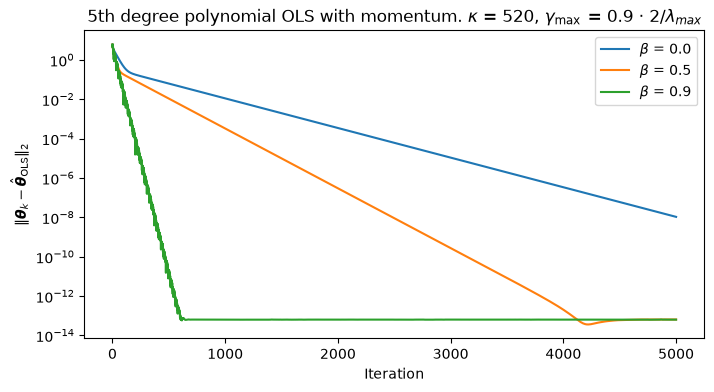

   beta = 0.0: first iteration with |theta - closed form| < 1e-6: 154
   beta = 0.5: first iteration with |theta - closed form| < 1e-6: 56
   beta = 0.9: first iteration with |theta - closed form| < 1e-6: 266


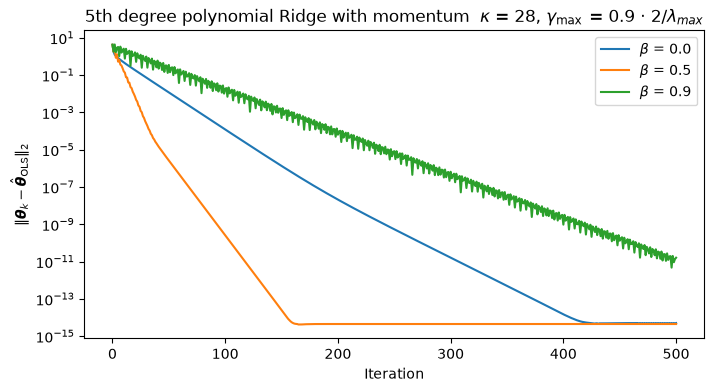

sqrt(kappa): 22.81105581634969 and [(sqrt(kappa) - 1) / (sqrt(kappa) + 1)]^2 = 0.839065901205715
   beta = 0.0: first iteration with |theta - closed form| < 1e-6: 3689
   beta = 0.5: first iteration with |theta - closed form| < 1e-6: 1829
   beta = 0.9: first iteration with |theta - closed form| < 1e-6: 284
   beta = 0.839065901205715: first iteration with |theta - closed form| < 1e-6: 517


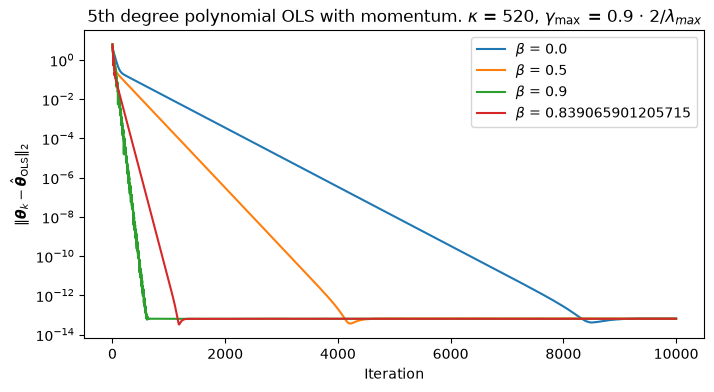

GD with no mumentum: 3689. GD with momentum:517, Ratio: 7.1353965183752415
Kappa: 520.3442674566211. Sqrt(kappa): 22.81105581634969, Ratio: 22.811055816349693


In [16]:
# Your momentum code here

"""Exercise 6.1"""
"""Tuesday seminar"""
def momentum_descent(X, y, gamma, beta, lam=0.0, num_iters=5000, tol=1e-8):
    """Gradient descent with momentum, Eq. (4.23). beta = 0 is plain gradient descent."""
    theta, v = np.zeros(X.shape[1]), np.zeros(X.shape[1])
    history = [theta.copy()]
    for t in range(num_iters):
        g = gradient(theta, X, y, lam)
        v = beta * v + gamma * g
        theta = theta - v
        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t + 1


betas = [0.0, 0.5, 0.9]


"""FOR OLS"""
eigvals_x5_OLS = hess_eigvals(X5_norm)
lmax_OLS, lmin_OLS = eigvals_x5_OLS.max(), eigvals_x5_OLS.min()
gamma_OLS = 0.9 * 2 / lmax_OLS
kappa_OLS = lmax_OLS / lmin_OLS


fig, ax = plt.subplots(figsize=(8,4))

for beta in betas:
    theta5_OLS, _ = momentum_descent(X5_norm, y_centered, gamma_OLS, beta, num_iters=5000,tol=0.0)
    dist = np.linalg.norm(theta5_OLS - X5_theta_cf_OLS, axis=1)
    first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
    ax.plot(range(len(dist)), dist, label=rf'$\beta$ = {beta}')
    print(f"   beta = {beta}: first iteration with |theta - closed form| < 1e-6: {first}")

ax.set_title(rf'5th degree polynomial OLS with momentum. $\kappa$ = {kappa_OLS:.0f}, $\gamma_{{\max}}$ = 0.9 $\cdot$ 2/$\lambda_{{max}}$')
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

"""FOR RIDGE"""

eigvals_x5_R = hess_eigvals(X5_norm, lam=lambus)
lmax_R, lmin_R = eigvals_x5_R.max(), eigvals_x5_R.min()
gamma_R = 0.9 * 2 / lmax_R
kappa_R = lmax_R / lmin_R

fig, ax = plt.subplots(figsize=(8,4))

for beta in betas:
    theta5_R, _ = momentum_descent(X5_norm, y_centered, gamma_OLS, beta, lam=lambus,num_iters=500,tol=0.0)
    dist = np.linalg.norm(theta5_R - X5_theta_cf_R, axis=1)
    first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
    ax.plot(range(len(dist)), dist, label=rf'$\beta$ = {beta}')
    print(f"   beta = {beta}: first iteration with |theta - closed form| < 1e-6: {first}")

ax.set_title(rf'5th degree polynomial Ridge with momentum  $\kappa$ = {kappa_R:.0f}, $\gamma_{{\max}}$ = 0.9 $\cdot$ 2/$\lambda_{{max}}$')
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

"""Exercie 6.2"""

"""FOR OLS"""
beta_star_OLS = ( (np.sqrt(kappa_OLS) - 1) / (np.sqrt(kappa_OLS) + 1) )**2
new_beta_list_OLS = [0.0, 0.5, 0.9, beta_star_OLS]
print(f'sqrt(kappa): {np.sqrt(kappa_OLS)} and [(sqrt(kappa) - 1) / (sqrt(kappa) + 1)]^2 = {beta_star_OLS}' )

fig, ax = plt.subplots(figsize=(8,4))
first_iteration = {} #converge val iteration per beta

for beta in new_beta_list_OLS:
    theta5_OLS, _ = momentum_descent(X5_norm, y_centered, gamma_OLS, beta, num_iters=10000,tol=0.0)
    dist = np.linalg.norm(theta5_OLS - X5_theta_cf_OLS, axis=1)
    first = np.argmax(dist < 1e-6) if np.any(dist < 1e-6) else None
    first_iteration[beta] = first
    ax.plot(range(len(dist)), dist, label=rf'$\beta$ = {beta}')
    print(f"   beta = {beta}: first iteration with |theta - closed form| < 1e-6: {first}")


ax.set_title(rf'5th degree polynomial OLS with momentum. $\kappa$ = {kappa_OLS:.0f}, $\gamma_{{\max}}$ = 0.9 $\cdot$ 2/$\lambda_{{max}}$')
ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Iteration')
ax.set_ylabel(r"$\|\boldsymbol{\theta}_k-\hat{\boldsymbol{\theta}}_{\mathrm{OLS}}\|_2$")
plt.show()

#Compare no monentum to momentum with betastar with gradient descent for ols
gd_no_mom = first_iteration[0.0]
gd_with_mom = first_iteration[beta_star_OLS]

print(f'GD with no mumentum: {gd_no_mom}. GD with momentum:{gd_with_mom}, Ratio: {gd_no_mom/gd_with_mom}')
print(f'Kappa: {kappa_OLS}. Sqrt(kappa): {np.sqrt(kappa_OLS)}, Ratio: {(kappa_OLS/np.sqrt(kappa_OLS))}')


## Insights you should have gained this week — a self-check

Before you hand in, go through the list below without looking at the notes.
Each row is a question we may ask in the Tuesday session or on Project 1; the
right-hand column is the insight it tests, in one sentence.

| Ask yourself | The insight it tests |
|---|---|
| My loop stopped after its allowed iterations with a small but nonzero gradient. Has it converged? | No. Along the slowest direction the error contracts by $\lvert 1-\gamma\lambda_{\min}\rvert$ per step, Eq. (4.19), and can still be $\|\nabla C\|/\lambda_{\min}$ large. Stop on the gradient (or on $\Delta\boldsymbol{\theta}$), never on a count alone. |
| Why does gradient descent care about the scaling of the columns when the closed form does not? | The closed form solves the normal equations in one go; gradient descent takes the same step in every direction, and the column scales set the eigenvalue spread $\kappa(\boldsymbol{H}) = \kappa_2(\boldsymbol{X})^2$, Eq. (4.22), hence the iteration count. Same minimum, different road. |
| Ridge converged in far fewer iterations than OLS. Did it find a better OLS solution? | No — it found the exact solution of a *different* problem, Eq. (4.16). The penalty lifts $\lambda_{\min}$, Eq. (4.17), which shortens the road, but the destination moved: bias traded for variance. |
| The same code diverged at $\gamma = 0.5$ on one data set and converged at $\gamma = 0.8$ on another. Why? | Stability requires $\gamma < 2/\lambda_{\max}$, Eq. (4.20), and $\lambda_{\max}$ is a property of $\boldsymbol{X}$, not of the algorithm. Compute it — `np.linalg.eigvalsh(2/n * X.T @ X).max()` — before you choose $\gamma$. |
| The closed form and my converged gradient descent disagree in the second decimal for Ridge. Which is wrong? | Possibly neither: with the cost $\frac{1}{n}\|\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y}\|^2 + \lambda\|\boldsymbol{\theta}\|^2$ the closed form has $n\lambda\boldsymbol{I}$, Eq. (3.95), and `scikit-learn`'s `alpha` is $n\lambda$. Compare cost functions before comparing methods. |
| My JAX gradient agrees with my analytical gradient to $10^{-15}$. What have I proved? | That your derivation matches the cost you *wrote down* — an algebra error would show as $10^{-2}$. Not that the cost is the one you meant (a missing $1/n$, a penalised intercept): both gradients would then agree and both would be wrong. |
| Momentum converged where plain gradient descent diverged. Is the learning rate now unimportant? | No. The stability edge moves to $2(1+\beta)/\lambda_{\max}$, and the best $\beta$ is tied to $\kappa$ through Eq. (4.26); too much momentum rings for ever. Two data-dependent knobs instead of one. |
| Why does momentum help, in one sentence? | It adds up gradients that keep pointing the same way (the flat directions, effective step $\gamma/(1-\beta)$, Eq. (4.25)) and cancels gradients that alternate in sign (the steep direction), so the iteration count scales with $\sqrt\kappa$ instead of $\kappa$. |
| I swap the OLS cost for a neural-network cost and keep `jax.grad`. What changes? | In the code: only the definition of the cost. In the theory: convexity is gone, so a stationary point need not be the global minimum (Section 4.1) and the bound of Eq. (4.20) is only local — good behaviour becomes empirical, not a theorem. |
| Why reverse mode for training, and what is its price? | One scalar output and $p$ inputs: reverse mode returns the full gradient for two or three cost evaluations, whatever $p$ (the cheap gradient principle, Section 4.14.4); forward mode or finite differences would need $p$ sweeps. The price is the tape — every intermediate value is stored until the backward sweep has used it: memory, not time. |
| Why not just use finite differences to check the gradient, and be done with it? | For a *quadratic* cost the central difference is exact up to rounding, so it would pass; for anything else its best accuracy is about $10^{-11}$ at $h\approx10^{-6}$, Eq. (4.46), and it costs $2p$ evaluations. Use it as a check at $h \approx 10^{-5}$, not as the gradient. |

### Practicalities

Deliver your solutions (a single Jupyter notebook, with the analytical parts
either typeset in Markdown/LaTeX or as a scanned handwritten note) in Canvas
before **Friday September 11 at midnight**. Collaboration is encouraged — list
your collaborators.